## just for figuring stuff out, not essential to the project

In [1]:
import numpy as np

In [5]:
A = np.zeros((1920, 1080, 3))

In [10]:
A[0, 1] = [1,2,3]

In [13]:
A

array([[[0., 0., 0.],
        [1., 2., 3.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], shape=(1920, 1080, 3))

In [1]:
import numpy as np

In [97]:
a = np.fromfile("./examples/sprites.bin", dtype=np.uint8)

In [98]:
a.shape

(32768,)

In [99]:
low_mask = (a & 0b00001111) # Lower part of each byte
high_mask = ((a & 0b11110000) >> 4) # Higher part of each byte: ofc we shifted to right

In [100]:
np.unique(low_mask)

array([ 0,  3,  4,  7,  8,  9, 10, 11, 12, 13], dtype=uint8)

In [101]:
np.unique(high_mask)

array([ 0,  3,  4,  7,  8,  9, 10, 11, 12, 13], dtype=uint8)

In [102]:
figure_buffer = np.zeros((256**2))

figure_buffer[::2] = high_mask # Even: the higher bigs
figure_buffer[1::2] = low_mask

In [103]:
figure_buffer = figure_buffer.reshape((256, 256))

In [10]:
import seaborn as sns 

In [105]:
from matplotlib.colors import ListedColormap

In [106]:
lista_colori = [
    '#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', 
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', 
    '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3'
]

mio_cmap = ListedColormap(lista_colori)


<Axes: >

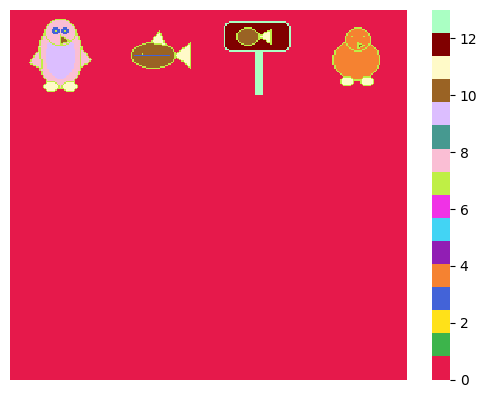

In [107]:
sns.heatmap(figure_buffer, cmap=mio_cmap, xticklabels=False, yticklabels=False)

In [3]:

from dataclasses import dataclass 

@dataclass 
class X:
    a: int 


In [5]:
X('hi')

X(a='hi')

In [6]:

from virtualvram import VirtualVRAM

In [18]:
V = VirtualVRAM("./examples/sprites.bin")

<Axes: >

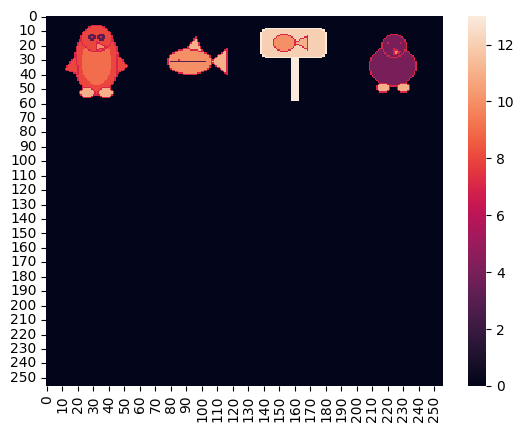

In [19]:
sns.heatmap(V.process_file())

In [1]:
from palette import Palette

In [2]:
p = Palette("./examples/palette.json")

In [3]:
p.initialize_palette()

In [40]:
import numpy as np

In [41]:
p.resolve_index_vectorized(np.array([[1,2,3], [1,2,3]])).shape

(2, 3, 3)

In [42]:
X = np.zeros((100, 100, 3), dtype=np.uint8)

In [54]:
X[1:30, 2:7] = np.ones((29, 5, 3))*(230)

In [55]:
X[2, 3]

array([230, 230, 230], dtype=uint8)

In [65]:
from virtualvram import VirtualVRAM
from palette import Palette


vram = VirtualVRAM('./examples/tiles.bin')
vram.process_file()

p = Palette("./examples/palette.json")
p.initialize_palette()

X =  p.resolve_index_vectorized(vram.get_buffer())

In [66]:
import matplotlib.pyplot as plt 

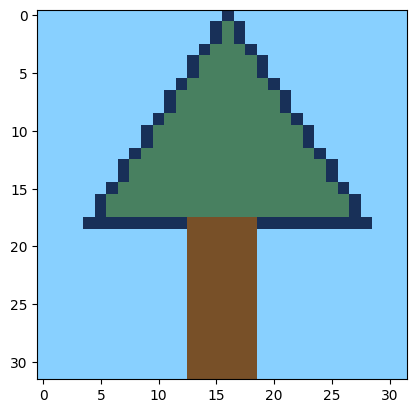

In [75]:
plt.imshow(X[32:32+32, 32:32+32])

In [1]:
from blitter import Blitter
from virtualvram import VirtualVRAM
from palette import Palette
import numpy as np
import matplotlib.pyplot as plt 

vram_tiles = VirtualVRAM('./examples/tiles.bin')
vram_tiles.process_file()

vram_sprites = VirtualVRAM('./examples/sprites.bin')
vram_sprites.process_file()

p = Palette("./examples/palette.json")
p.initialize_palette()

b = Blitter(vram_tiles, vram_sprites, p)


In [3]:
import random

In [10]:
k = 5
X = np.zeros((32*k, 32*k, 3), dtype=np.uint8)

for i in range(k**2):
    x,y = divmod(i, k)
    b.extract_draw_tile(X, 9, x, y)

for i in range(k**2):
    x,y = divmod(i, k)
    b.extract_draw_sprite(X, 0, x*random.randint(1, 30), y*random.randint(1,30), random.choice([True, False]), random.choice([True, False]), random.choice([0, 90, 180, 270]), 0)


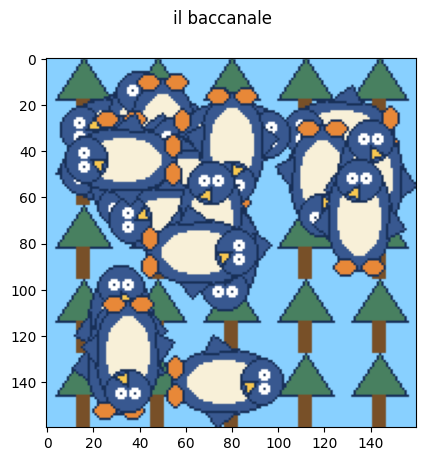

In [14]:
plt.imshow(X)
plt.suptitle("il baccanale")
plt.show()

In [15]:
A = [
    [2, 3, 5]
]

In [16]:
for (i, r) in enumerate(A):
    for (j, x) in enumerate(r):
        print(i, j, type(x))

0 0 <class 'int'>
0 1 <class 'int'>
0 2 <class 'int'>
